In [1]:
import sys
# Add parent directory to path to import file_paths module
sys.path.insert(0, '..')
import file_paths
import helper_functions

import eelbrain
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats

Gammatone filterbank:   0%|          | 0/128 [00:00<?, ?band/s]

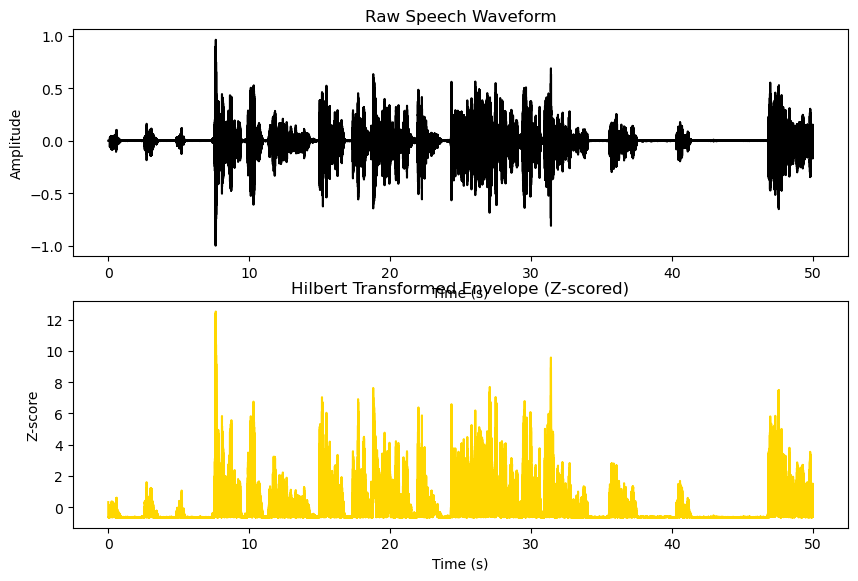

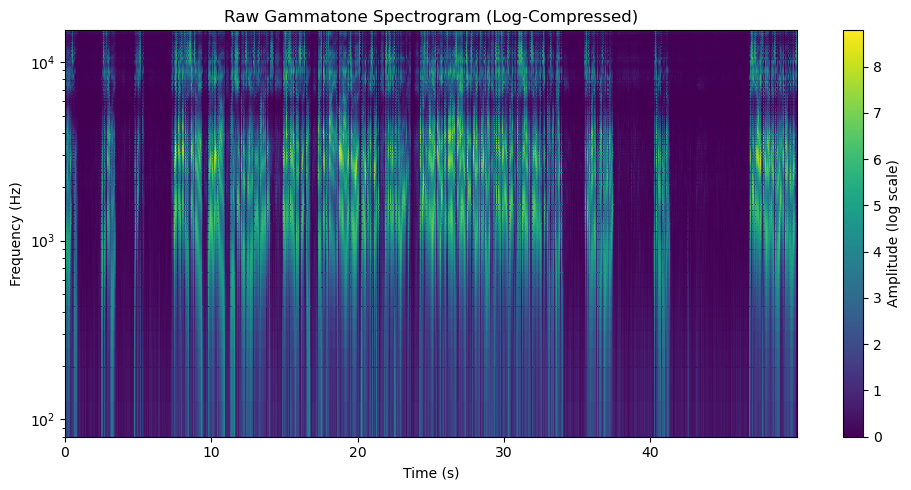

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import eelbrain
from scipy.io import wavfile
from scipy.signal import hilbert

# --- Helper: z-score ---
def zscore(x):
    return (x - np.mean(x)) / np.std(x)

STIMULUS = 'aske_story1_trial_10.wav'
stim_path = file_paths.STIMULUS_DIR / STIMULUS

# --- Load audio ---
fs, audio = wavfile.read(stim_path)

# Convert to mono if needed
if len(audio.shape) > 1:
    audio = audio.mean(axis=1)

# Normalize waveform for stability
audio = audio / np.max(np.abs(audio))

# Time axis
t = np.arange(len(audio)) / fs

# --- Hilbert envelope ---
analytic_signal = hilbert(audio)
envelope = np.abs(analytic_signal)

# --- Gammatone filterbank (time-frequency representation) ---
wav = eelbrain.load.wav(stim_path)
gt = eelbrain.gammatone_bank(
    wav,
    80,          # low frequency
    15000,       # high frequency
    128,         # number of filters
    location='left',
    tstep=0.001  # 1 ms step
)

# Log-transform & z-score for stability
gt_log = (gt + 1).log()
gt_log_z = zscore(gt_log.x)  # z-score over time and frequency
t_gt = gt.time.times
f_gt = np.linspace(80, 15000, gt_log.shape[0])  # approximate frequency axis

# --- Plot ---
plt.figure(figsize=(10, 10))

# 1. Raw waveform
plt.subplot(3, 1, 1)
plt.plot(t, audio, color='black')
plt.title("Raw Speech Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

# 2. Hilbert envelope (z-scored)
plt.subplot(3, 1, 2)
plt.plot(t, zscore(envelope), color='gold')
plt.title("Hilbert Transformed Envelope (Z-scored)")
plt.xlabel("Time (s)")
plt.ylabel("Z-score")

'''
# 3. Gammatone Time-Frequency Representation (Log + Z-scored)
plt.subplot(3, 1, 3)
plt.pcolormesh(t_gt, f_gt, gt_log_z, shading='gouraud', cmap='viridis')
plt.title("Gammatone Time-Frequency Representation (Log + Z-scored)")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.colorbar(label="Z-score")
plt.yscale('log')  # optional, cochlear-like
plt.tight_layout()
plt.show()
'''

# --- Raw Gammatone Spectrogram (log-compressed for visibility) ---
gt_raw = gt  # raw gammatone spectrogram
t_gt = gt_raw.time.times
f_gt = np.linspace(80, 15000, gt_raw.shape[0])  # approximate frequency axis

# Mild log compression to make low-amplitude bands visible
gt_vis = np.log1p(gt_raw.x)  # log(1 + x)

plt.figure(figsize=(10, 5))
plt.pcolormesh(t_gt, f_gt, gt_vis, shading='gouraud', cmap='viridis')
plt.title("Raw Gammatone Spectrogram (Log-Compressed)")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.colorbar(label="Amplitude (log scale)")
plt.yscale('log')  # cochlear-like scaling
plt.tight_layout()
plt.show()



Gammatone filterbank:   0%|          | 0/128 [00:00<?, ?band/s]

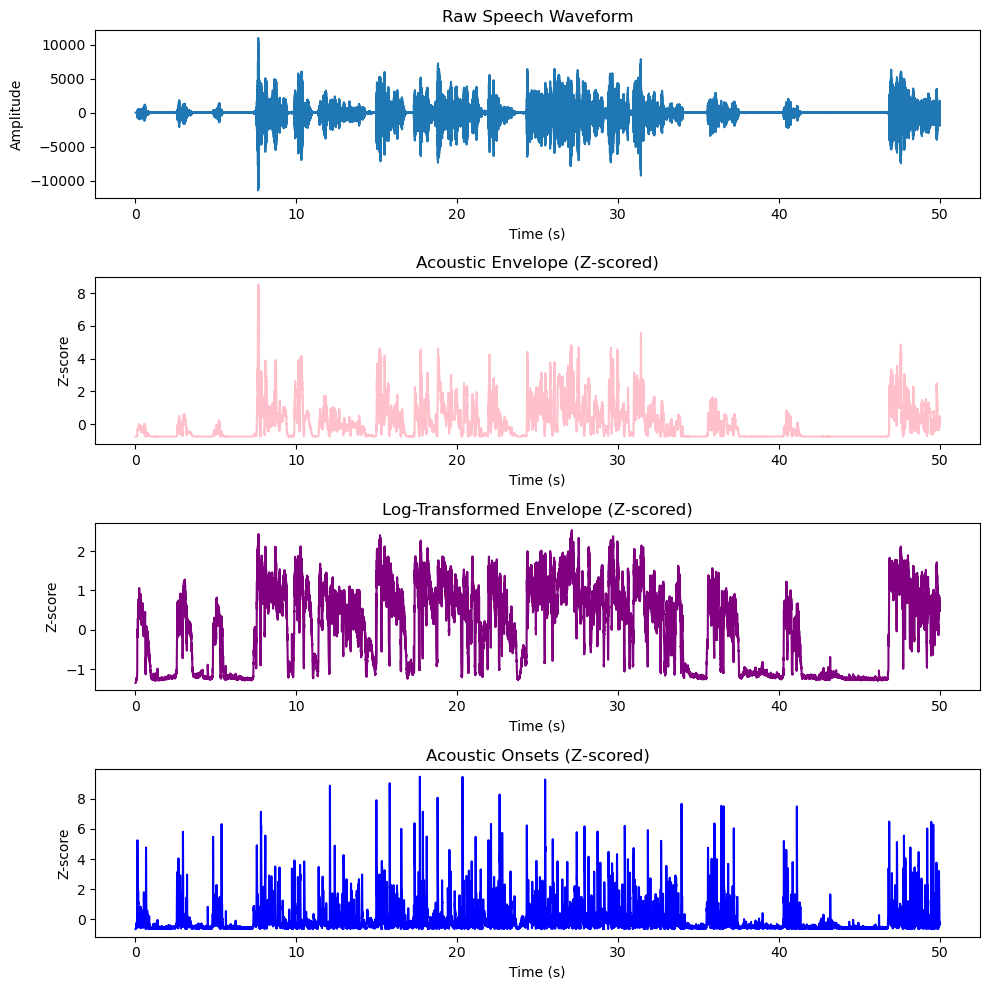

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import eelbrain

# --- Helper: z-score ---
def zscore(x):
    return (x - np.mean(x)) / np.std(x)

# --- Load stimulus ---
STIMULUS = 'aske_story1_trial_10.wav'
stim_path = file_paths.STIMULUS_DIR / STIMULUS

wav = eelbrain.load.wav(stim_path)

# --- Gammatone filterbank ---
gt = eelbrain.gammatone_bank(
    wav,
    80,
    15000,
    128,
    location='left',
    tstep=0.001
)

# --- Envelope variants ---
gt_sum = gt.sum('frequency')

gt_log = (gt + 1).log()
gt_log_sum = gt_log.sum('frequency')

gt_onset = eelbrain.edge_detector(gt_log, c=30)
gt_onset_sum = gt_onset.sum('frequency')

# --- Time axis ---
t = gt_sum.time.times

# --- Raw waveform ---
audio = wav.x
fs = int(1 / wav.time.tstep)
t_audio = np.arange(len(audio)) / fs

# --- Plot ---
plt.figure(figsize=(10, 10))

# 1. Raw waveform (NOT normalized)
plt.subplot(4, 1, 1)
plt.plot(t_audio, audio)
plt.title("Raw Speech Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

# 2. Gammatone envelope (z-scored)
plt.subplot(4, 1, 2)
plt.plot(t, zscore(gt_sum.x), color='pink')
plt.title("Acoustic Envelope (Z-scored)")
plt.xlabel("Time (s)")
plt.ylabel("Z-score")

# 3. Log envelope (z-scored)
plt.subplot(4, 1, 3)
plt.plot(t, zscore(gt_log_sum.x), color='purple')
plt.title("Log-Transformed Envelope (Z-scored)")
plt.xlabel("Time (s)")
plt.ylabel("Z-score")

# 4. Acoustic onset (z-scored)
plt.subplot(4, 1, 4)
plt.plot(t, zscore(gt_onset_sum.x), color='blue')
plt.title("Acoustic Onsets (Z-scored)")
plt.xlabel("Time (s)")
plt.ylabel("Z-score")

plt.tight_layout()
plt.show()

